## Regularization - Weights & Biases decay
The goal of this notebook is to test the effect of regularization in terms of weights and biases decay on the performance of SGD optimizer under a linear regression problem.
We will use a synthetic dataset generated using `sklearn.datasets.make_regression` function. The dataset will consist of a specified number of samples and features, and we will introduce some noise to make the problem more realistic.

In [1]:
import numpy as np
from core.dataset.dataset import DataLoader, TensorDataset
from core.tensor import Tensor
from examples.linear_regression.helpers.dataset import preprocess_dataloader, split_dataset
from sklearn.datasets import make_regression

SEED = 888
BIAS = 7.2
NOISE = 80
BATCH_SIZE = 16

X, y, true_coefs = make_regression(n_samples=100, n_features=1, n_targets=1, bias=BIAS, noise=NOISE, coef=True, random_state=SEED)

true_coefs = np.array([true_coefs])

X, y = X, y.reshape(-1, 1)

X_tr, X_te = split_dataset(X, axis=0)
y_tr, y_te = split_dataset(y, axis=0)

print(X_tr.shape)

data_tr = TensorDataset(Tensor(X_tr), Tensor(y_tr))
data_te = TensorDataset(Tensor(X_te), Tensor(y_te))

tr_dataloader, te_dataloader = DataLoader(data_tr, BATCH_SIZE), DataLoader(data_te, BATCH_SIZE)


(90, 1)


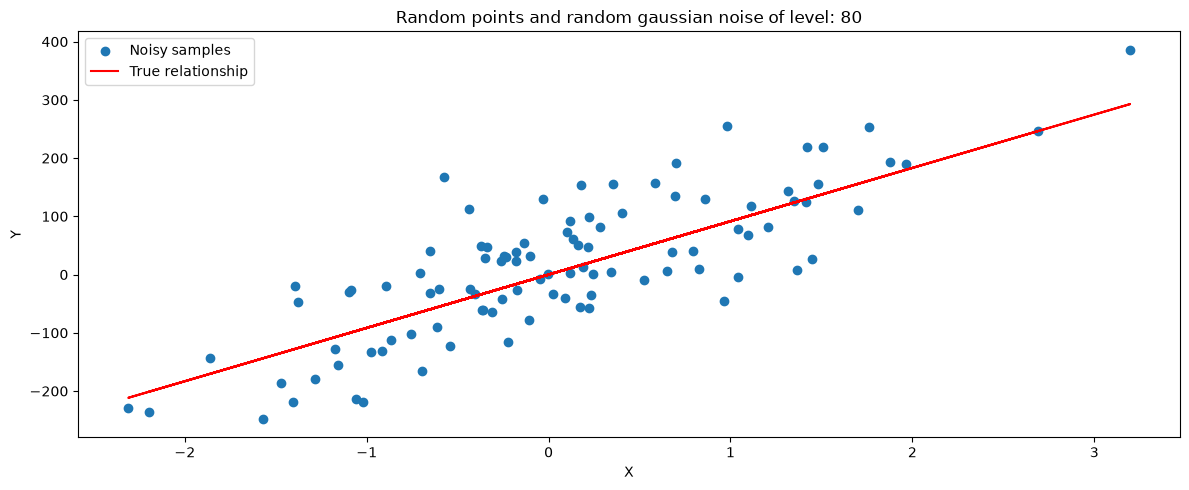

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax) = plt.subplots(1, 1, figsize=(12, 5))

ax.scatter(X, y, label="Noisy samples")
ax.plot(X, X@true_coefs, color="red", label="True relationship")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title(f"Random points and random gaussian noise of level: {NOISE}")
ax.legend()

fig.tight_layout()
plt.show()

## Training: decay in isolation

The dataset remain the same across all training runs, the goals is to test the decay coefficients in isolation, with a high variance dataset.

This experiment comprend three different scenarios:
1. No weight decay: 1 dimension of training:
- - several trials on the same dataset

2. Weight decay: 2 dimension of training:
- - several trials for the same decay coefficients with increasing decay coefficients

3. Weight decay + Bias decay: 2 dimension of training:
- - several trials for the same decay coefficients with increasing decay coefficients

## 1. No weight decay

In this scenario we will train the model without any weight decay, and we will evaluate the performance of the model on the test set. We will use a learning rate scheduler and SGD optimizer. 
We will also plot the training and validation loss curves to visualize the performance of the model.

In [ ]:
"""Training over the same sample for N_TRIALS, for compute the mean loss."""

from examples.linear_regression.helpers.train import create_trainer, fit_model

EPOCHS = 80
EVAL_STEP = 10
N_TRIALS = 5
MAX_LR, MIN_LR = 1e-2, 1e-4

trainers = [create_trainer(1, 1, MIN_LR, MAX_LR, EPOCHS) for _ in range(N_TRIALS)]

assert len(trainers) == N_TRIALS
for i, trainer in zip(range(N_TRIALS), trainers):
    fit_model(trainer, tr_dataloader, te_dataloader, EPOCHS, EVAL_STEP)




## Loss history and weights interpretation